<a href="https://colab.research.google.com/github/ThaoAnnh/HTCNWEB-/blob/main/VoThaoAnh_23693011_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 01 – Image Basics – STUDENT

**Google Colab · Python · OpenCV · NumPy**

## Mục tiêu
- Biểu diễn ảnh như ma trận NumPy.
- Tự cài BGR→Gray.
- Brightness/contrast, resize, crop.

## 0. Chuẩn bị môi trường

In [8]:
!pip -q install scikit-image
import cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd, time, os
from pathlib import Path
print("OpenCV:", cv2.__version__); print("NumPy:", np.__version__)
def show_image(image,title="Image",cmap=None,figsize=(6,6)):
    plt.figure(figsize=figsize)
    if image.ndim==3: plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    else: plt.imshow(image,cmap=cmap or "gray")
    plt.title(title); plt.axis("off"); plt.show()
def show_images(images,titles=None,cols=3,figsize=(15,8)):
    n=len(images); rows=int(np.ceil(n/cols)); plt.figure(figsize=figsize)
    for i,img in enumerate(images):
        plt.subplot(rows,cols,i+1)
        plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB)) if img.ndim==3 else plt.imshow(img,cmap="gray")
        if titles: plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout(); plt.show()

OpenCV: 5.0.0
NumPy: 2.0.2


### Dữ liệu demo chạy ngay

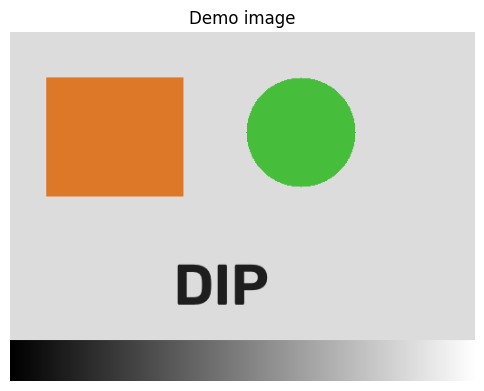

In [9]:
def create_demo_image(w=512,h=384):
    img=np.full((h,w,3),220,dtype=np.uint8)
    cv2.rectangle(img,(40,50),(190,180),(40,120,220),-1)
    cv2.circle(img,(320,110),60,(60,190,70),-1)
    cv2.putText(img,"DIP",(180,300),cv2.FONT_HERSHEY_SIMPLEX,2.2,(30,30,30),5)
    for x in range(w):
        v=int(255*x/(w-1)); img[h-45:h,x]=(v,v,v)
    return img
image=create_demo_image(); gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY); show_image(image,"Demo image")

### Tùy chọn upload ảnh thật

In [10]:
from google.colab import files
uploaded=files.upload()
filename=list(uploaded.keys())[0]
image=cv2.imread(filename)
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

Saving anh tphcm.jpg to anh tphcm (1).jpg


## 1. Khám phá ảnh

Shape: (640, 960, 3)
Shape: (640, 960, 3)
Dtype: uint8
Min pixel: 0
Max pixel: 255
Pixel [100, 100]: [157 138 171]
Min từng kênh BGR: [0 0 0]
Max từng kênh BGR: [255 255 255]


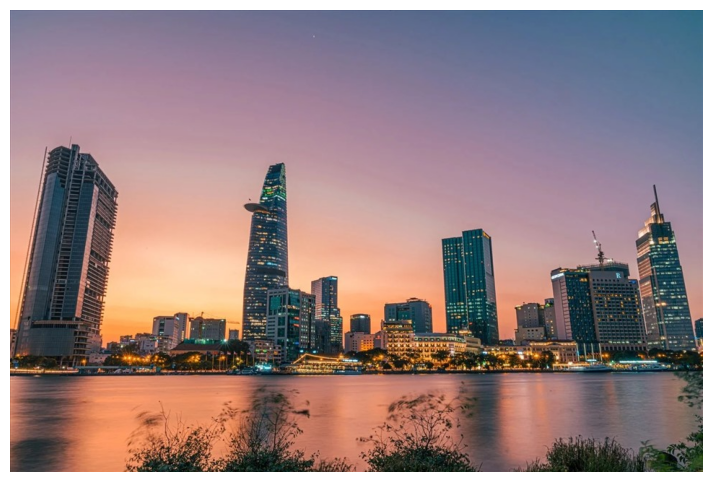

In [16]:
print("Shape:",image.shape)
# TODO: dtype, min, max, pixel

print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Min pixel:", image.min())
print("Max pixel:", image.max())

# Lấy pixel tại vị trí (100, 100)
print("Pixel [100, 100]:", image[100, 100])

# Thông tin từng kênh BGR
print("Min từng kênh BGR:", image.min(axis=(0, 1)))
print("Max từng kênh BGR:", image.max(axis=(0, 1)))

# Hiển thị ảnh
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 2. BGR → Gray

Sai khác lớn nhất: 1


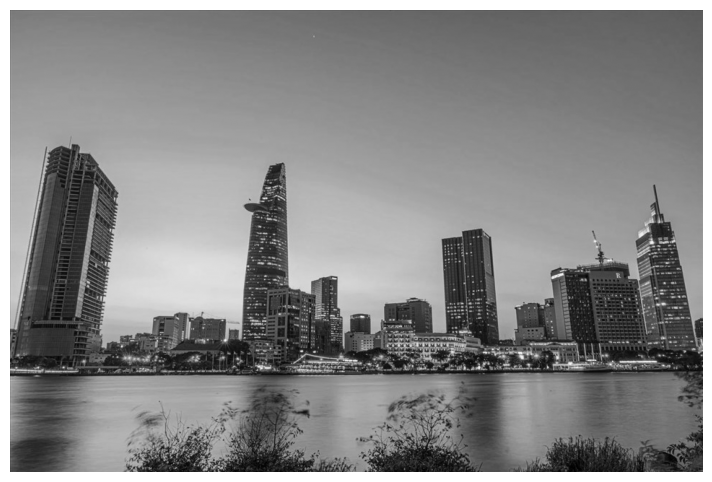

In [18]:
def my_bgr_to_gray(img):
    # TODO: tách B,G,R; tính công thức; clip; uint8
    B = img[:, :, 0].astype(np.float32)
    G = img[:, :, 1].astype(np.float32)
    R = img[:, :, 2].astype(np.float32)

    gray = 0.114 * B + 0.587 * G + 0.299 * R

    gray = np.clip(gray, 0, 255).astype(np.uint8)

    return gray

    pass


# TODO: đối chiếu cv2.cvtColor
gray_my = my_bgr_to_gray(image)
gray_cv = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Sai khác lớn nhất:", np.max(
    np.abs(gray_my.astype(np.int16) - gray_cv.astype(np.int16))
))

# Hiển thị ảnh Gray
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(gray_my, cmap="gray")
plt.axis("off")
plt.show()

## 3. Brightness/Contrast

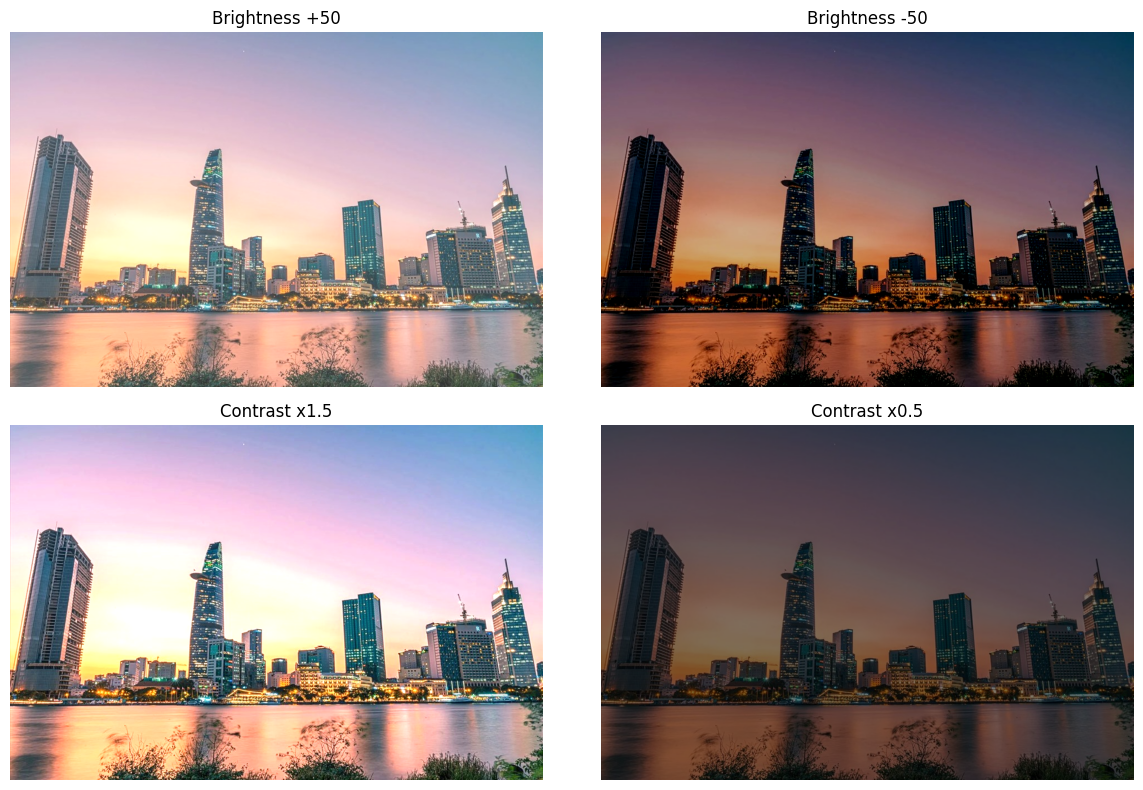

In [19]:
def adjust_bc(img,alpha=1,beta=0):
    # TODO
    result = img.astype(np.float32)

    # Công thức Brightness / Contrast
    result = alpha * result + beta

    # Clip giá trị pixel
    result = np.clip(result, 0, 255)

    # Chuyển về uint8
    result = result.astype(np.uint8)

    pass

    return result

# TODO: thử 4 bộ tham số
result1 = adjust_bc(image, alpha=1, beta=50)
result2 = adjust_bc(image, alpha=1, beta=-50)
result3 = adjust_bc(image, alpha=1.5, beta=0)
result4 = adjust_bc(image, alpha=0.5, beta=0)

import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(result1, cv2.COLOR_BGR2RGB))
plt.title("Brightness +50")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
plt.title("Brightness -50")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(result3, cv2.COLOR_BGR2RGB))
plt.title("Contrast x1.5")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(result4, cv2.COLOR_BGR2RGB))
plt.title("Contrast x0.5")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Resize/Crop/Flip

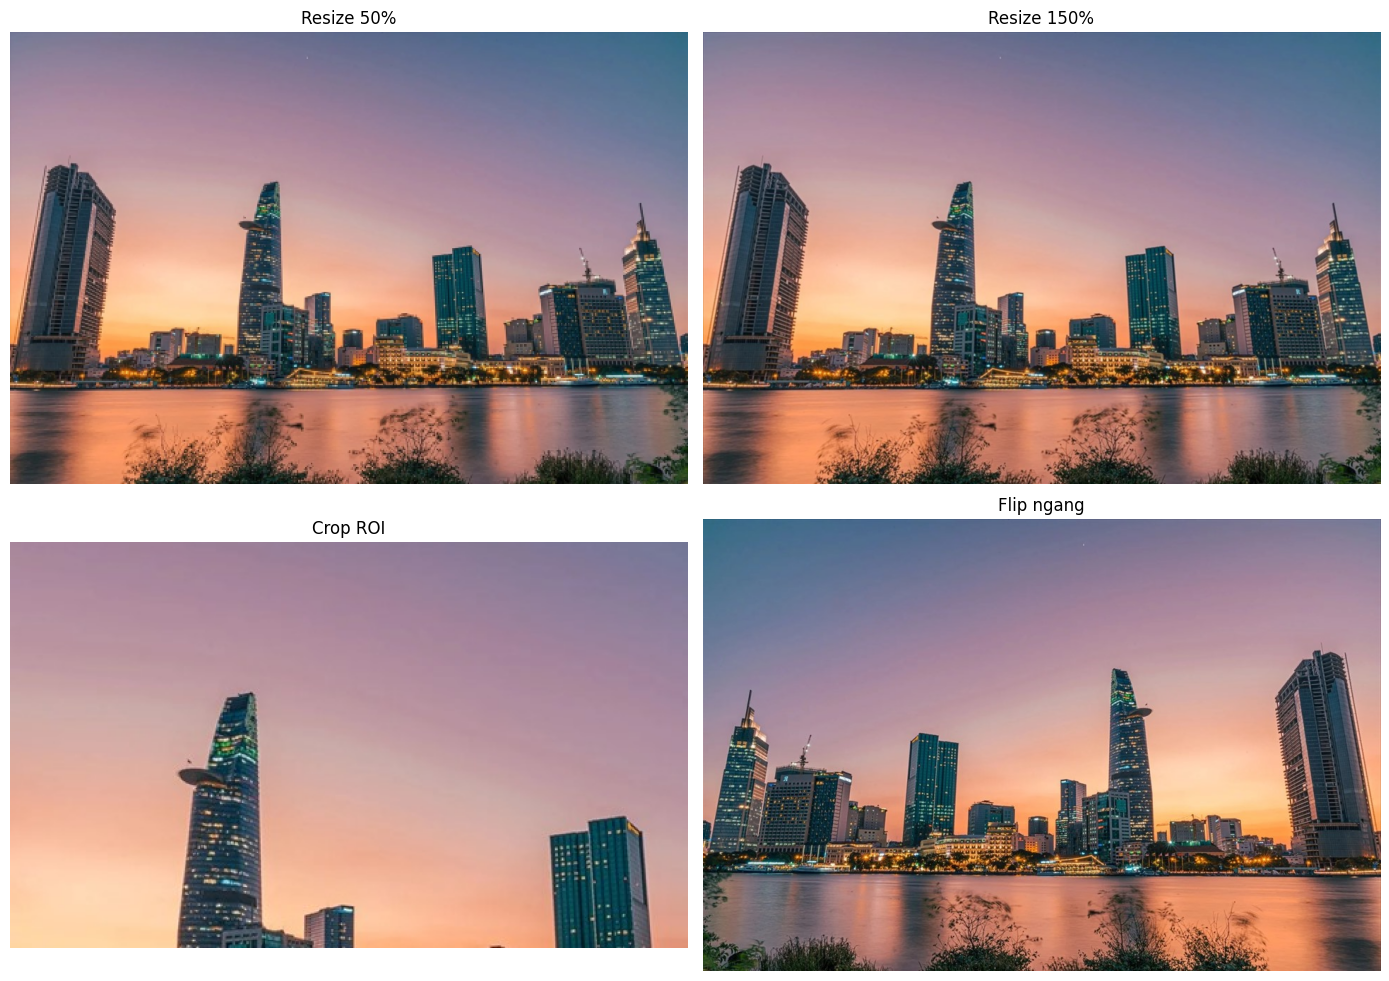

In [20]:
# TODO: resize 50%, 150%, crop ROI, flip ngang
resize_50 = cv2.resize(image, None, fx=0.5, fy=0.5)
resize_150 = cv2.resize(image, None, fx=1.5, fy=1.5)

crop = image[100:400, 200:700]

flip = cv2.flip(image, 1)

# Hiển thị
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(resize_50, cv2.COLOR_BGR2RGB))
plt.title("Resize 50%")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(resize_150, cv2.COLOR_BGR2RGB))
plt.title("Resize 150%")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Crop ROI")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(flip, cv2.COLOR_BGR2RGB))
plt.title("Flip ngang")
plt.axis("off")

plt.tight_layout()
plt.show()

## Kết quả cần nộp
- Notebook đã chạy.
- Ảnh kết quả + nhận xét.
- So sánh tham số/phương pháp.
- Ít nhất 1 failure case.

# **12. Câu hỏi phân tích bắt buộc**

**Câu 1. Tại sao OpenCV đọc ảnh theo BGR nhưng Matplotlib hiển thị RGB?**


- OpenCV sử dụng thứ tự màu BGR, nghĩa là Blue, Green, Red. Trong khi đó, Matplotlib sử dụng thứ tự RGB, nghĩa là Red, Green, Blue.

- Vì vậy, nếu dùng ảnh đọc bằng OpenCV để hiển thị trực tiếp bằng Matplotlib thì màu sắc có thể bị đảo. Cần chuyển ảnh từ BGR sang RGB trước khi hiển thị.

In [26]:
# Đọc ảnh bằng OpenCV
image = cv2.imread("/content/anh tphcm (1).jpg")

# Kiểm tra thứ tự kênh màu
print(image[100, 100])

# Chuyển BGR sang RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

[157 138 171]


**Câu 2. Shape, size và dtype cho biết những thông tin gì?**

Shape cho biết kích thước của ảnh. Với ảnh màu, shape thường có ba giá trị gồm chiều cao, chiều rộng và số kênh màu.

In [30]:
print("Shape:", image.shape)
print("Size:", image.size)
print("Dtype:", image.dtype)

Shape: (640, 960, 3)
Size: 1843200
Dtype: uint8


**Câu 3. Vì sao pixel thường được truy cập bằng image[y, x]?**

Ảnh được lưu dưới dạng một ma trận. Trong ma trận, y biểu thị vị trí hàng và x biểu thị vị trí cột.

Vì vậy, khi lấy một pixel ta sử dụng image[y, x].

In [29]:
# Lấy pixel tại hàng 100, cột 200
pixel = image[100, 200]

print("Pixel:", pixel)

Pixel: [155 134 167]


**Câu 4. cv2.split() và NumPy slicing khác nhau như thế nào?**

- Cả hai cách đều có thể dùng để tách các kênh màu của ảnh.

- Với cv2.split(), ta có thể tách ảnh thành ba kênh B, G và R.

In [28]:
# Tách bằng cv2.split()
B, G, R = cv2.split(image)

# Tách bằng NumPy slicing
B2 = image[:, :, 0]
G2 = image[:, :, 1]
R2 = image[:, :, 2]

print("Kích thước kênh B:", B.shape)
print("Kích thước kênh G:", G.shape)
print("Kích thước kênh R:", R.shape)

Kích thước kênh B: (640, 960)
Kích thước kênh G: (640, 960)
Kích thước kênh R: (640, 960)


**Câu 5. Công thức chuyển BGR hoặc RGB sang Gray dựa trên cơ sở nào?**

Khi chuyển ảnh màu sang ảnh xám, không lấy trung bình đơn giản của ba kênh màu. Công thức sử dụng các trọng số khác nhau vì mắt người có độ nhạy khác nhau đối với từng màu.

Với ảnh BGR, công thức thường dùng là:

**Gray = 0.114 × B + 0.587 × G + 0.299 × R**

Kênh Green có trọng số lớn nhất vì mắt người nhạy với màu xanh lá nhiều hơn so với xanh dương.

In [31]:
# Tách B, G, R
B = image[:, :, 0].astype(np.float32)
G = image[:, :, 1].astype(np.float32)
R = image[:, :, 2].astype(np.float32)

# Chuyển sang ảnh xám
gray = 0.114 * B + 0.587 * G + 0.299 * R

# Đưa về khoảng 0 đến 255
gray = np.clip(gray, 0, 255).astype(np.uint8)

print("Shape ảnh Gray:", gray.shape)
print("Dtype ảnh Gray:", gray.dtype)

Shape ảnh Gray: (640, 960)
Dtype ảnh Gray: uint8


**Câu 6. Interpolation ảnh hưởng đến chất lượng resize như thế nào?**

- Khi thay đổi kích thước ảnh, kích thước mới có thể không có sẵn các pixel tương ứng với ảnh ban đầu. Interpolation là phương pháp dùng để tính giá trị của các pixel mới.

- Các phương pháp nội suy khác nhau sẽ cho chất lượng ảnh khác nhau.

- Nearest Neighbor thực hiện nhanh nhưng ảnh có thể bị răng cưa.

- Bilinear cho ảnh mượt hơn và thường được sử dụng khi resize ảnh.

- Bicubic cho chất lượng tốt hơn nhưng thời gian tính toán lâu hơn.

In [34]:
# Resize bằng Nearest Neighbor
resize_nearest = cv2.resize(
    image, None,
    fx=1.5,
    fy=1.5,
    interpolation=cv2.INTER_NEAREST
)

# Resize bằng Bilinear
resize_linear = cv2.resize(
    image, None,
    fx=1.5,
    fy=1.5,
    interpolation=cv2.INTER_LINEAR
)

# Resize bằng Bicubic
resize_cubic = cv2.resize(
    image, None,
    fx=1.5,
    fy=1.5,
    interpolation=cv2.INTER_CUBIC
)

print("Ảnh gốc:", image.shape)
print("Nearest:", resize_nearest.shape)
print("Linear:", resize_linear.shape)
print("Cubic:", resize_cubic.shape)

Ảnh gốc: (640, 960, 3)
Nearest: (960, 1440, 3)
Linear: (960, 1440, 3)
Cubic: (960, 1440, 3)


**Câu 7. Vì sao xoay ảnh bằng warpAffine có thể làm mất một phần ảnh?**

- Khi xoay ảnh, một số phần của ảnh có thể bị đưa ra ngoài phạm vi của khung ảnh ban đầu.

- Nếu vẫn giữ nguyên kích thước khung ảnh thì những phần nằm bên ngoài khung sẽ bị cắt mất.

In [35]:
# Lấy kích thước ảnh
h, w = image.shape[:2]

# Tạo ma trận xoay 45 độ
M = cv2.getRotationMatrix2D(
    (w // 2, h // 2),
    45,
    1
)

# Xoay ảnh nhưng giữ kích thước cũ
rotated = cv2.warpAffine(
    image,
    M,
    (w, h)
)

print("Kích thước ảnh gốc:", image.shape)
print("Kích thước sau khi xoay:", rotated.shape)

Kích thước ảnh gốc: (640, 960, 3)
Kích thước sau khi xoay: (640, 960, 3)


**Câu 8. Alpha và beta ảnh hưởng brightness và contrast như thế nào?**

- Alpha dùng để điều chỉnh độ tương phản của ảnh.

- Beta dùng để điều chỉnh độ sáng của ảnh.

Công thức được sử dụng là:

kết quả = alpha × pixel + beta

- Khi alpha lớn hơn 1, độ tương phản tăng.

- Khi alpha nhỏ hơn 1, độ tương phản giảm.

- Khi beta lớn hơn 0, ảnh sáng hơn.

- Khi beta nhỏ hơn 0, ảnh tối hơn.

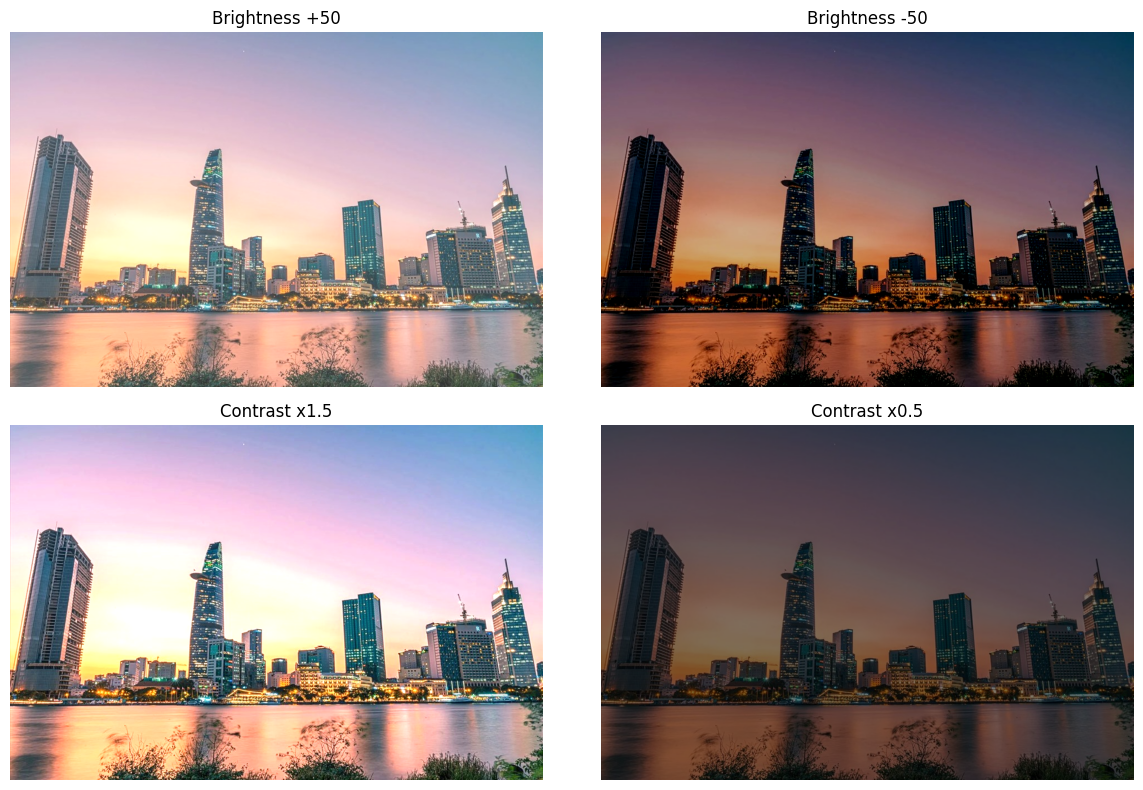

In [39]:
def adjust_bc(img, alpha=1, beta=0):
    # TODO
    result = img.astype(np.float32)

    # Công thức Brightness / Contrast
    result = alpha * result + beta

    # Clip giá trị pixel
    result = np.clip(result, 0, 255)

    # Chuyển về uint8
    result = result.astype(np.uint8)

    pass

    return result


# Thử 4 bộ tham số
result1 = adjust_bc(image, alpha=1, beta=50)
result2 = adjust_bc(image, alpha=1, beta=-50)
result3 = adjust_bc(image, alpha=1.5, beta=0)
result4 = adjust_bc(image, alpha=0.5, beta=0)


# Hiển thị 4 ảnh
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(result1, cv2.COLOR_BGR2RGB))
plt.title("Brightness +50")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
plt.title("Brightness -50")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(result3, cv2.COLOR_BGR2RGB))
plt.title("Contrast x1.5")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(result4, cv2.COLOR_BGR2RGB))
plt.title("Contrast x0.5")
plt.axis("off")

plt.tight_layout()
plt.show()

**Câu 9. Vì sao nên clip về khoảng 0 đến 255 trước khi chuyển sang uint8?**

- Kiểu dữ liệu uint8 chỉ có thể lưu các giá trị từ 0 đến 255.

- Trong quá trình xử lý ảnh, phép tính có thể tạo ra các giá trị nhỏ hơn 0 hoặc lớn hơn 255.

- Ví dụ, khi tăng độ sáng, một pixel có giá trị 230 cộng thêm 50 sẽ thành 280. Giá trị 280 không thể lưu trực tiếp bằng uint8.

- Vì vậy cần sử dụng np.clip() để đưa các giá trị về khoảng từ 0 đến 255 trước khi chuyển sang uint8.

In [37]:
# Tạo một số giá trị vượt ngoài khoảng 0 đến 255
result = np.array([-50, 100, 280], dtype=np.float32)

print("Trước khi clip:", result)

# Đưa giá trị về khoảng 0 đến 255
result = np.clip(result, 0, 255)

print("Sau khi clip:", result)

# Chuyển sang uint8
result = result.astype(np.uint8)

print("Sau khi chuyển uint8:", result)

Trước khi clip: [-50. 100. 280.]
Sau khi clip: [  0. 100. 255.]
Sau khi chuyển uint8: [  0 100 255]


**Câu 10. Tại sao phép cộng NumPy uint8 có thể khác cv2.add()?**

- Khi cộng hai mảng có kiểu uint8 bằng NumPy, có thể xảy ra hiện tượng tràn số vì uint8 chỉ có thể lưu giá trị từ 0 đến 255.

Ví dụ:

a = np.array([250], dtype=np.uint8)
b = np.array([10], dtype=np.uint8)


print(a + b)

- Phép tính thực tế là 250 cộng 10 bằng 260, nhưng 260 lớn hơn giới hạn của uint8.

- Trong khi đó, cv2.add() sử dụng cách cộng có giới hạn. Nếu kết quả lớn hơn 255 thì kết quả được giữ ở 255.

In [36]:
# Tạo hai giá trị uint8
a = np.array([250], dtype=np.uint8)
b = np.array([10], dtype=np.uint8)

# Cộng bằng NumPy
numpy_result = a + b

# Cộng bằng OpenCV
opencv_result = cv2.add(a, b)

print("Kết quả NumPy:", numpy_result)
print("Kết quả OpenCV:", opencv_result)

Kết quả NumPy: [4]
Kết quả OpenCV: [[260.]
 [  0.]
 [  0.]
 [  0.]]
